# Getting Started with QuScope

Welcome to QuScope! This tutorial will guide you through the basics of using QuScope v0.2.0 for quantum-enhanced microscopy analysis.

## About

QuScope is a Python package that applies quantum computing algorithms to electron microscopy image processing and EELS analysis. Built on [Qiskit](https://qiskit.org/), it provides a unified, hardware-agnostic interface for quantum-enhanced microscopy workflows.

**What's new in v0.2.0:**
- Unified backend abstraction (`get_backend`) for simulators and IBM Quantum hardware
- `BackendConfig` for shot and execution control
- Pre-defined material library (`get_material`) with lattice parameters and scattering properties
- `QuantumWaveEncoder` for amplitude-based wavefunction encoding
- Quantum CTEM and STEM simulation pipelines
- Improved multislice and CTF envelope support

**Key capabilities:**
- Quantum CTEM (Conventional Transmission Electron Microscopy) simulation
- Quantum STEM simulation
- Quantum image encoding and processing
- EELS quantum analysis
- Integration with IBM Quantum hardware

## Installation

If you haven't already installed QuScope v0.2.0:

```bash
pip install quscope==0.2.0
```

## 1. Basic Imports and Setup

Let's start by importing the necessary modules:

In [ ]:
import sys, subprocess
result = subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "quscope==0.2.0"], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

In [1]:
import quscope
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

# QuScope quantum CTEM modules
from quscope.quantum_ctem.backends import get_backend
from quscope.quantum_ctem.materials import get_material

print(f"QuScope version: {quscope.__version__}")
print("Setup complete!")

Matplotlib is building the font cache; this may take a moment.


QuScope version: 0.2.0
Setup complete!


## 2. Working with Quantum Backends

QuScope provides a unified backend abstraction for quantum simulators and real quantum hardware.

In [2]:
# Get a simulator backend (no IBM credentials needed)
backend = get_backend('simulator')
backend.connect()

print(f"Backend type: {backend.__class__.__name__}")
print("Backend initialized successfully")

# Create a simple Bell state circuit
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

print("\nBell state circuit:")
print(qc)

# Execute the circuit using the backend.run() method
from quscope.quantum_ctem.backends import BackendConfig

config = BackendConfig(shots=1000)
result = backend.run(qc, config)
counts = result.counts

print("\nMeasurement results:")
for state, count in sorted(counts.items()):
    print(f"  |{state}⟩: {count} times ({count/10:.1f}%)")

Backend type: SimulatorBackend
Backend initialized successfully

Bell state circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Measurement results:
  |00⟩: 501 times (50.1%)
  |11⟩: 499 times (49.9%)


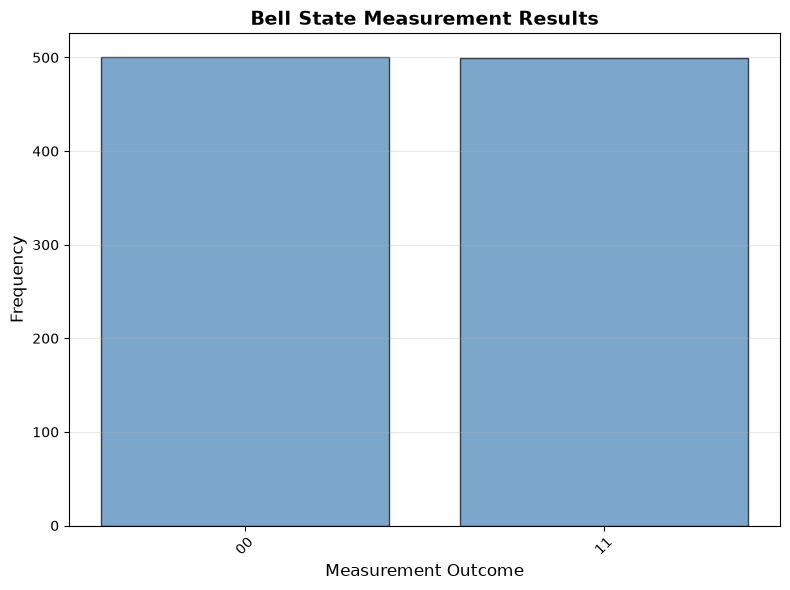


Total shots: 1000
Outcome |00⟩: 501 times
Outcome |11⟩: 499 times


In [3]:
# Visualize the results
states = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(8, 6))
plt.bar(states, values, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Measurement Outcome', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Bell State Measurement Results', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal shots: {sum(values)}")
print(f"Outcome |00⟩: {counts.get('00', 0)} times")
print(f"Outcome |11⟩: {counts.get('11', 0)} times")

## 3. Loading Materials

QuScope includes pre-defined materials with their atomic structures and scattering properties.

In [4]:
# Load MoS2 material
mos2 = get_material('mos2')

print(f"Material: {mos2.name}")
print(f"Formula: {mos2.formula}")
print(f"\nLattice parameters:")
print(f"  a = {mos2.parameters.a:.3f} Å")
print(f"  c = {mos2.parameters.c:.3f} Å")
print(f"\nElements: {mos2.parameters.elements}")
print(f"Space group: {mos2.parameters.space_group}")
print(f"Typical thickness: {mos2.parameters.typical_thickness:.1f} Å")

Material: Molybdenum Disulfide
Formula: MoS₂

Lattice parameters:
  a = 3.160 Å
  c = 12.290 Å

Elements: ['Mo', 'S']
Space group: P-3m1
Typical thickness: 6.5 Å


In [5]:
# Load Graphene material
graphene = get_material('graphene')

print(f"Material: {graphene.name}")
print(f"Formula: {graphene.formula}")
print(f"\nLattice parameters:")
print(f"  a = {graphene.parameters.a:.3f} Å")
print(f"  c = {graphene.parameters.c:.3f} Å")
print(f"\nElements: {graphene.parameters.elements}")
print(f"Space group: {graphene.parameters.space_group}")
print(f"Typical thickness: {graphene.parameters.typical_thickness:.1f} Å")

Material: Graphene
Formula: C

Lattice parameters:
  a = 2.460 Å
  c = 3.350 Å

Elements: ['C']
Space group: P6/mmm
Typical thickness: 3.4 Å


## 4. Simple Quantum Image Encoding

Let's encode a small image into a quantum circuit.

Test wavefunction (4×4):
[[0.         0.08638684 0.34554737 0.43193421]
 [0.04319342 0.12958026 0.30235395 0.38874079]
 [0.08638684 0.17277369 0.25916053 0.34554737]
 [0.12958026 0.21596711 0.21596711 0.30235395]]


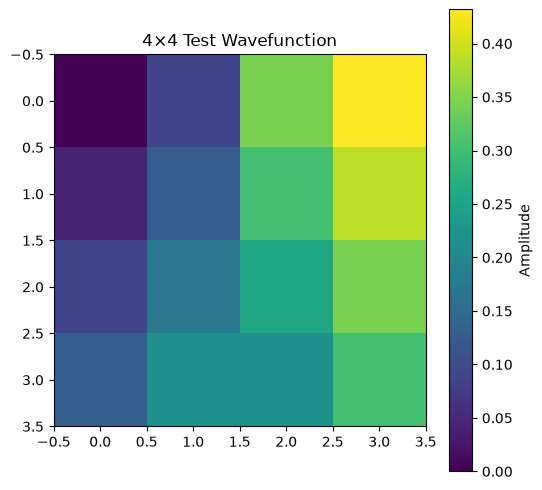

In [6]:
# Quantum Wave Function Encoding
from quscope.quantum_ctem.quantum_encoding import QuantumWaveEncoder

# Create a simple 4x4 test image (representing a 2D wavefunction)
test_image = np.array([
    [0.0, 0.2, 0.8, 1.0],
    [0.1, 0.3, 0.7, 0.9],
    [0.2, 0.4, 0.6, 0.8],
    [0.3, 0.5, 0.5, 0.7]
])

# Normalize the image
test_image_normalized = test_image / np.linalg.norm(test_image)

print("Test wavefunction (4×4):")
print(test_image_normalized)

# Visualize the wavefunction
plt.figure(figsize=(6, 6))
plt.imshow(test_image_normalized, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Amplitude')
plt.title('4×4 Test Wavefunction')
plt.show()

In [7]:
# Encode wavefunction to quantum circuit
encoder = QuantumWaveEncoder(grid_size=4)  # 4x4 grid requires 2 qubits per dimension

# Use amplitude encoding
circuit = encoder.encode_amplitude(test_image_normalized)

print(f"Quantum encoded circuit:")
print(f"  Qubits: {circuit.num_qubits}")
print(f"  Depth: {circuit.depth()}")
print(f"  Gates: {circuit.size()}")

# Visualize the circuit structure
print(f"\nCircuit structure:")
print(circuit)

Quantum Wave Encoder initialized:
  Grid size: 4×4
  Qubits per dimension: 2
  Total qubits: 4
  Quantum state space: 2^4 = 16
  Classical array size: 16
  Exponential advantage: 1.0×
Quantum encoded circuit:
  Qubits: 4
  Depth: 1
  Gates: 1

Circuit structure:
       »
psi_0: »
       »
psi_1: »
       »
psi_2: »
       »
psi_3: »
       »
«       ┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
«psi_0: ┤0                                                                                                                                          ├
«       │                                                                                                                                           │
«psi_1: ┤1                                                                                                                                          ├
«       │  Initialize(0,0.086387,0.34555,0.43193,0.04319

## 5. Quantum State Analysis

Let's analyze the quantum state created by our encoding.

In [8]:
from qiskit.quantum_info import Statevector

# Get the statevector from the encoded circuit (only works with simulators)
statevector = Statevector.from_instruction(circuit)

# Get probabilities
probabilities = statevector.probabilities()

# Compare with flattened, normalized wavefunction
flattened_normalized = test_image_normalized.flatten()

print("Quantum State Analysis:")
print("=" * 60)
print(f"Total probability: {np.sum(probabilities):.6f}")
print(f"\nFirst 8 basis states and their amplitudes:")

for i in range(min(8, len(probabilities))):
    amplitude = np.sqrt(probabilities[i])
    expected = flattened_normalized[i]
    print(f"  |{i:04b}⟩: amplitude = {amplitude:.4f}, expected = {expected:.4f}")

Quantum State Analysis:
Total probability: 1.000000

First 8 basis states and their amplitudes:
  |0000⟩: amplitude = 0.0000, expected = 0.0000
  |0001⟩: amplitude = 0.0864, expected = 0.0864
  |0010⟩: amplitude = 0.3455, expected = 0.3455
  |0011⟩: amplitude = 0.4319, expected = 0.4319
  |0100⟩: amplitude = 0.0432, expected = 0.0432
  |0101⟩: amplitude = 0.1296, expected = 0.1296
  |0110⟩: amplitude = 0.3024, expected = 0.3024
  |0111⟩: amplitude = 0.3887, expected = 0.3887
